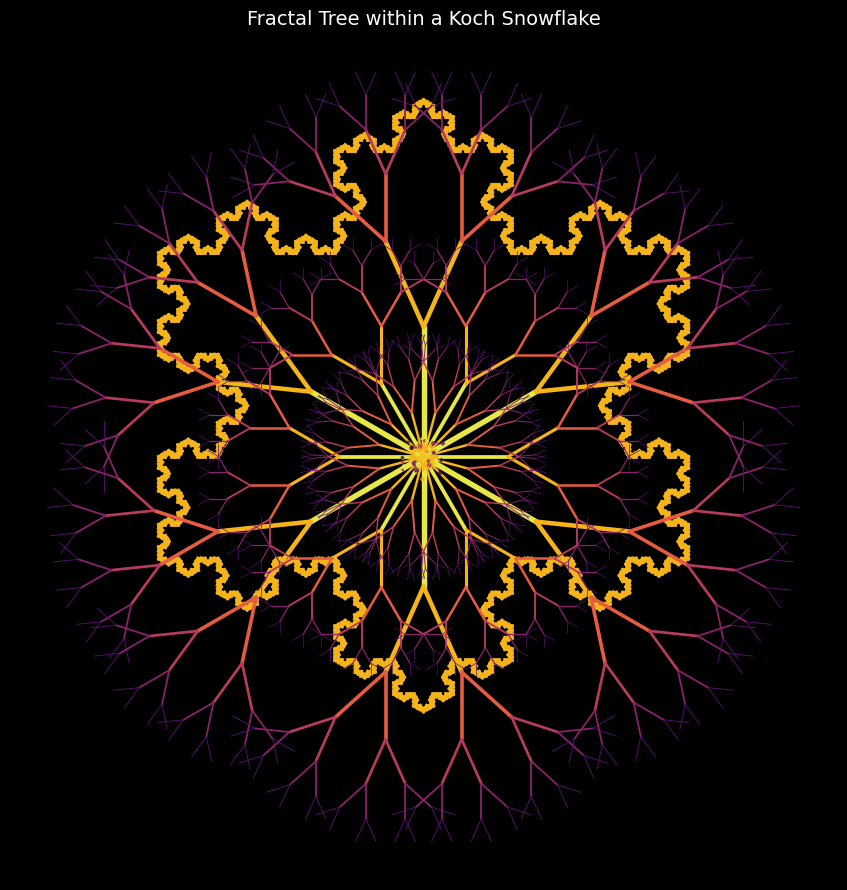

In [6]:
import matplotlib.pyplot as plt
import numpy as np

colors = ['#2b0b3f', '#57106e', '#8a226b', '#b83b5e', '#e65c40', '#f4b41a', '#e7e846']

# ---------- Koch snowflake (outer boundary) ----------
def koch_segment(x1, y1, x2, y2, depth, max_depth, ax):
    if depth == 0:
        color = colors[max_depth % len(colors)]
        ax.plot([x1, x2], [y1, y2], color=color, lw=max(0.6, (max_depth - depth) * 0.4 + 0.6))
        return
    dx, dy = (x2 - x1) / 3, (y2 - y1) / 3
    xa, ya = x1 + dx, y1 + dy
    xb, yb = x1 + 2 * dx, y1 + 2 * dy
    angle = np.radians(-60)
    px = xa + (xb - xa) * np.cos(angle) - (yb - ya) * np.sin(angle)
    py = ya + (xb - xa) * np.sin(angle) + (yb - ya) * np.cos(angle)
    koch_segment(x1, y1, xa, ya, depth - 1, max_depth, ax)
    koch_segment(xa, ya, px, py, depth - 1, max_depth, ax)
    koch_segment(px, py, xb, yb, depth - 1, max_depth, ax)
    koch_segment(xb, yb, x2, y2, depth - 1, max_depth, ax)

def draw_snowflake(ax, size, depth):
    h = size * np.sqrt(3) / 2
    p1, p2, p3 = (-size/2, -h/3), (size/2, -h/3), (0, 2*h/3)
    koch_segment(*p1, *p2, depth, depth, ax)
    koch_segment(*p2, *p3, depth, depth, ax)
    koch_segment(*p3, *p1, depth, depth, ax)

# ---------- Recursive branching tree ----------
def draw_branch(ax, x, y, angle, length, depth, spread=25, shrink=0.72, lw_scale=0.6):
    if depth == 0 or length < 0.8:
        return
    x_end = x + length * np.cos(np.radians(angle))
    y_end = y + length * np.sin(np.radians(angle))
    color = colors[depth % len(colors)]
    ax.plot([x, x_end], [y, y_end], color=color, lw=max(0.5, depth * lw_scale), solid_capstyle='round')
    draw_branch(ax, x_end, y_end, angle - spread, length * shrink, depth - 1, spread, shrink, lw_scale)
    draw_branch(ax, x_end, y_end, angle + spread, length * shrink, depth - 1, spread, shrink, lw_scale)

def draw_tree_star(ax, cx, cy, length, depth, n_arms=6, rot_offset=0, **kwargs):
    for i in range(n_arms):
        angle = 90 + rot_offset + i * (360 / n_arms)
        draw_branch(ax, cx, cy, angle, length, depth, **kwargs)

# ---------- Decorative core ----------
def draw_core(ax, cx, cy, r_outer):
    n_glow = 25
    for i, r in enumerate(np.linspace(r_outer, 1, n_glow)):
        t = i / n_glow
        color = colors[int(t * (len(colors) - 1))]
        circ = plt.Circle((cx, cy), r, color=color, alpha=0.05, zorder=1)
        ax.add_patch(circ)

    n_points = 12
    r_out, r_in = r_outer * 0.9, r_outer * 0.35
    angles = np.linspace(0, 2 * np.pi, n_points * 2, endpoint=False)
    pts = []
    for i, a in enumerate(angles):
        r = r_out if i % 2 == 0 else r_in
        pts.append((cx + r * np.cos(a), cy + r * np.sin(a)))
    pts.append(pts[0])
    xs, ys = zip(*pts)
    ax.plot(xs, ys, color='#f4b41a', lw=1.4, zorder=4)
    ax.fill(xs, ys, color='#e7e846', alpha=0.35, zorder=3)

    rng = np.random.default_rng(7)
    n_sparks = 40
    spark_r = rng.uniform(r_outer * 0.4, r_outer * 1.6, n_sparks)
    spark_a = rng.uniform(0, 2 * np.pi, n_sparks)
    sx = cx + spark_r * np.cos(spark_a)
    sy = cy + spark_r * np.sin(spark_a)
    sizes = rng.uniform(2, 14, n_sparks)
    spark_colors = [colors[i % len(colors)] for i in rng.integers(0, len(colors), n_sparks)]
    ax.scatter(sx, sy, s=sizes, c=spark_colors, alpha=0.8, zorder=5, linewidths=0)

# ---------- Compose ----------
fig, ax = plt.subplots(figsize=(9, 9), facecolor='black')
ax.set_facecolor('black')

snow_size, snow_depth = 200, 5
draw_snowflake(ax, size=snow_size, depth=snow_depth)

h = snow_size * np.sqrt(3) / 2
cx, cy = 0, -h / 9
base_length = (h / 3) * 0.85

draw_tree_star(ax, cx, cy, length=base_length, depth=6, n_arms=6,
                rot_offset=0, spread=24, shrink=0.72, lw_scale=0.65)
draw_tree_star(ax, cx, cy, length=base_length * 0.65, depth=6, n_arms=6,
                rot_offset=30, spread=30, shrink=0.68, lw_scale=0.45)
draw_tree_star(ax, cx, cy, length=base_length * 0.35, depth=5, n_arms=12,
                rot_offset=15, spread=20, shrink=0.7, lw_scale=0.35)

draw_core(ax, cx, cy, r_outer=base_length * 0.12)

ax.set_aspect('equal')
ax.axis('off')
plt.title("Fractal Tree within a Koch Snowflake", color="white", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

colors = ['#2b0b3f', '#57106e', '#8a226b', '#b83b5e', '#e65c40', '#f4b41a', '#e7e846']

def koch_segment(x1, y1, x2, y2, depth, max_depth, ax):
    if depth == 0:
        color = colors[max_depth % len(colors)]
        ax.plot([x1, x2], [y1, y2], color=color, lw=max(0.6, (max_depth - depth) * 0.4 + 0.6))
        return
    dx, dy = (x2 - x1) / 3, (y2 - y1) / 3
    xa, ya = x1 + dx, y1 + dy
    xb, yb = x1 + 2 * dx, y1 + 2 * dy
    angle = np.radians(-60)
    px = xa + (xb - xa) * np.cos(angle) - (yb - ya) * np.sin(angle)
    py = ya + (xb - xa) * np.sin(angle) + (yb - ya) * np.cos(angle)
    koch_segment(x1, y1, xa, ya, depth - 1, max_depth, ax)
    koch_segment(xa, ya, px, py, depth - 1, max_depth, ax)
    koch_segment(px, py, xb, yb, depth - 1, max_depth, ax)
    koch_segment(xb, yb, x2, y2, depth - 1, max_depth, ax)

def draw_snowflake(ax, size, depth):
    h = size * np.sqrt(3) / 2
    p1, p2, p3 = (-size/2, -h/3), (size/2, -h/3), (0, 2*h/3)
    koch_segment(*p1, *p2, depth, depth, ax)
    koch_segment(*p2, *p3, depth, depth, ax)
    koch_segment(*p3, *p1, depth, depth, ax)

def draw_branch(ax, x, y, angle, length, depth, spread=25, shrink=0.72, lw_scale=0.6):
    if depth == 0 or length < 0.8:
        return
    x_end = x + length * np.cos(np.radians(angle))
    y_end = y + length * np.sin(np.radians(angle))
    color = colors[depth % len(colors)]
    ax.plot([x, x_end], [y, y_end], color=color, lw=max(0.5, depth * lw_scale), solid_capstyle='round')
    draw_branch(ax, x_end, y_end, angle - spread, length * shrink, depth - 1, spread, shrink, lw_scale)
    draw_branch(ax, x_end, y_end, angle + spread, length * shrink, depth - 1, spread, shrink, lw_scale)

def draw_tree_star(ax, cx, cy, length, depth, n_arms=6, rot_offset=0, **kwargs):
    for i in range(n_arms):
        angle = 90 + rot_offset + i * (360 / n_arms)
        draw_branch(ax, cx, cy, angle, length, depth, **kwargs)

def draw_core(ax, cx, cy, r_outer):
    n_glow = 25
    for i, r in enumerate(np.linspace(r_outer, 1, n_glow)):
        t = i / n_glow
        color = colors[int(t * (len(colors) - 1))]
        ax.add_patch(plt.Circle((cx, cy), r, color=color, alpha=0.05, zorder=1))
    n_points = 12
    r_out, r_in = r_outer * 0.9, r_outer * 0.35
    angles = np.linspace(0, 2 * np.pi, n_points * 2, endpoint=False)
    pts = []
    for i, a in enumerate(angles):
        r = r_out if i % 2 == 0 else r_in
        pts.append((cx + r * np.cos(a), cy + r * np.sin(a)))
    pts.append(pts[0])
    xs, ys = zip(*pts)
    ax.plot(xs, ys, color='#f4b41a', lw=1.4, zorder=4)
    ax.fill(xs, ys, color='#e7e846', alpha=0.35, zorder=3)
    rng = np.random.default_rng(7)
    n_sparks = 40
    spark_r = rng.uniform(r_outer * 0.4, r_outer * 1.6, n_sparks)
    spark_a = rng.uniform(0, 2 * np.pi, n_sparks)
    sx = cx + spark_r * np.cos(spark_a)
    sy = cy + spark_r * np.sin(spark_a)
    sizes = rng.uniform(2, 14, n_sparks)
    spark_colors = [colors[i % len(colors)] for i in rng.integers(0, len(colors), n_sparks)]
    ax.scatter(sx, sy, s=sizes, c=spark_colors, alpha=0.8, zorder=5, linewidths=0)

def draw_frame(ax, max_depth):
    ax.clear()
    ax.set_facecolor('black')
    snow_size = 200
    snow_depth = min(max_depth, 5)
    draw_snowflake(ax, size=snow_size, depth=snow_depth)
    h = snow_size * np.sqrt(3) / 2
    cx, cy = 0, -h / 9
    base_length = (h / 3) * 0.85
    tree_depth = min(max_depth, 6)
    draw_tree_star(ax, cx, cy, length=base_length, depth=tree_depth, n_arms=6,
                    rot_offset=0, spread=24, shrink=0.72, lw_scale=0.65)
    draw_tree_star(ax, cx, cy, length=base_length * 0.65, depth=tree_depth, n_arms=6,
                    rot_offset=30, spread=30, shrink=0.68, lw_scale=0.45)
    draw_tree_star(ax, cx, cy, length=base_length * 0.35, depth=min(max_depth, 5), n_arms=12,
                    rot_offset=15, spread=20, shrink=0.7, lw_scale=0.35)
    if max_depth >= tree_depth:
        draw_core(ax, cx, cy, r_outer=base_length * 0.12)
    ax.set_xlim(-110, 110)
    ax.set_ylim(-110, 130)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"Fractal Tree within a Koch Snowflake  (depth {max_depth})",
                 color="white", fontsize=13)

fig, ax = plt.subplots(figsize=(7, 7), facecolor='black')

max_depth_overall = 6
frames = list(range(1, max_depth_overall + 1)) + [max_depth_overall] * 8  # hold last frame

def update(frame_depth):
    draw_frame(ax, frame_depth)
    return ax.artists + ax.lines

ani = animation.FuncAnimation(fig, update, frames=frames, interval=600, blit=False)

ani.save('fractal_growth.gif', writer='pillow', fps=2)

try:
    ani.save('fractal_growth.mp4', writer='ffmpeg', fps=2, dpi=150)
except Exception as e:
    print("MP4 export skipped (install ffmpeg to enable):", e)

plt.close(fig)

MovieWriter ffmpeg unavailable; using Pillow instead.


MP4 export skipped (install ffmpeg to enable): unknown file extension: .mp4
